# 605 Companies Inc. — Haul Route & Cycle-Time Optimization Pipeline
**Target Project:** SD DOT PCN 05HN (I-229 Exit 4 / Cliff Ave Reconstruction)  
**Objective:** Calculate optimal commercial haul routes between local aggregate suppliers and the I-229 reconstruction zone to minimize fuel consumption, transit cycle times, and bidding costs.

In [3]:
import osmnx as ox
import networkx as nx
import geopandas as gpd

print("Core geospatial dependencies successfully imported.")

Core geospatial dependencies successfully imported.


### 1. Spatial Anchor Definition
* **Origin:** Concrete Materials / Aggregate Yard (North Sioux Falls)
* **Destination:** SD DOT Active Construction Zone (I-229 & Cliff Ave Interchange)
* **Purpose:** Establish exact coordinates for the haul origin-destination pair within Minnehaha County.

In [4]:
# Origin: Concrete Materials Aggregate Pit (North Sioux Falls)
ORIGIN_POINT = (43.5828, -96.7265) 

# Destination: I-229 & Cliff Ave Work Zone
DEST_POINT = (43.5222, -96.7118)

print(f"Origin Anchor: {ORIGIN_POINT}")
print(f"Destination Anchor: {DEST_POINT}")

Origin Anchor: (43.5828, -96.7265)
Destination Anchor: (43.5222, -96.7118)


### 2. Driveable Network Ingestion
* Queries the regional road network within a 12 km radius of the corridor.
* Filters strictly for **driveable roads** (excluding non-vehicular paths).
* Exports the resulting road segments as a GeoJSON layer for spatial visualization in **QGIS**.

In [5]:
import os

In [6]:
# 1. Ensure the output directory exists
os.makedirs("data/processed", exist_ok=True)

# 2. Download driveable road network surrounding the corridor
graph = ox.graph_from_point(ORIGIN_POINT, dist=12000, network_type='drive')

# 3. Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph)

# 4. Convert any list-type columns to strings so GeoJSON can serialize them
for col in edges.columns:
    if edges[col].apply(lambda x: isinstance(x, list)).any():
        edges[col] = edges[col].astype(str)

# 5. Export to GeoJSON
edges.to_file("data/processed/minnehaha_drive_network.geojson", driver="GeoJSON")

print(f"Extraction Complete: {len(nodes):,} intersections and {len(edges):,} road segments saved.")

#has been saved and ready for a new push into github

Extraction Complete: 8,317 intersections and 22,800 road segments saved.


In [7]:
import geopandas as gpd
import pandas as pd

# 1. Read the saved GeoJSON file directly into a GeoDataFrame
edges_gdf = gpd.read_file("data/processed/minnehaha_drive_network.geojson")

# 2. Inspect the unique highway classifications in our network
print("Unique road classifications in Minnehaha County:")
print(edges_gdf['highway'].value_counts().head(10))

Unique road classifications in Minnehaha County:
highway
[residential]       15598
[tertiary]           2910
[secondary]          1960
[unclassified]        979
[primary]             732
[motorway_link]       270
[motorway]            112
[trunk]                99
[primary_link]         32
[secondary_link]       31
Name: count, dtype: int64


c:\Users\lozak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


### Algorithm Development: Road Network Classification

**Objective:** Inspect extracted Minnehaha County graph edges to prepare for speed-limit mapping and commercial routing weight penalties.

**Output Verification:**

| Highway Classification | Segment Count | Percentage |
| :--- | :--- | :--- |
| **Residential** | 15,598 | 68.6% |
| **Tertiary** | 2,910 | 12.8% |
| **Secondary** | 1,960 | 8.6% |
| **Unclassified** | 979 | 4.3% |
| **Primary** | 732 | 3.2% |
| **Motorway Link** | 270 | 1.2% |
| **Motorway** | 112 | 0.5% |
| **Trunk** | 99 | 0.4% |
| **Primary Link** | 32 | 0.1% |
| **Secondary Link** | 31 | 0.1% |
| **Total** | **22,723** | **100%** |

**Strategic Implication:** The road network is heavily skewed toward residential segments (68.6%). To model a realistic and legal commercial hauling route for 605 Companies Inc., a baseline travel speed matrix must be constructed to enforce a strong algorithmic preference for primary, secondary, and motorway segments.

In [9]:
import numpy as np
import geopandas as gpd

# 0. Reload the GeoJSON file into memory so edges_gdf is defined
edges_gdf = gpd.read_file("data/processed/minnehaha_drive_network.geojson")

# 1. Define baseline speeds (mph) tailored for heavy commercial haulers
commercial_speeds_mph = {
    'motorway': 65,         # Interstate 229
    'motorway_link': 45,    # On/Off ramps
    'trunk': 55,            # Major state highways (SD 11)
    'primary': 45,          # Major arterials (Minnesota Ave)
    'secondary': 35,        # Minor arterials (Cliff Ave, 57th St)
    'tertiary': 30,         # Collector roads (Ralph Rogers Rd)
    'unclassified': 25,     # Rural/county roads
    'residential': 20       # Residential streets (heavy time penalty)
}

# 2. Function to resolve highway classes and assign legal travel speeds
def assign_speed(row):
    hw_type = row['highway']
    
    # Handle segments with multiple classification tags (lists or numpy arrays)
    if isinstance(hw_type, (list, np.ndarray)):
        hw_type = hw_type[0]
        
    return commercial_speeds_mph.get(hw_type, 20)

# 3. Apply the speed matrix to all network edges
edges_gdf['assigned_speed_mph'] = edges_gdf.apply(assign_speed, axis=1)

# 4. Convert mph to meters per minute (1 mph = 26.8224 meters/minute)
edges_gdf['speed_mpm'] = edges_gdf['assigned_speed_mph'] * 26.8224

# 5. Calculate edge travel time cost in minutes: Cost = Length / Speed
edges_gdf['travel_time_min'] = edges_gdf['length'] / edges_gdf['speed_mpm']

# 6. Verify calculated weights across sample road corridors
sample_cols = ['name', 'highway', 'length', 'assigned_speed_mph', 'travel_time_min']
display(edges_gdf[sample_cols].head(5))

c:\Users\lozak\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


,name,highway,length,assigned_speed_mph,travel_time_min
0,[South Quail Run Avenue],[residential],86.790102,20,0.161787
1,[South Quail Run Avenue],[residential],92.849762,20,0.173083
2,[East 61st Street],[residential],298.013605,20,0.555531
3,[East 61st Street],[residential],165.835908,20,0.309137
4,[South Quail Run Avenue],[residential],84.865165,20,0.158198


In [9]:
# 1. Drop duplicates to keep exactly one example of every road classification
verification_df = edges_gdf.drop_duplicates(subset=['highway']).copy()

# 2. Sort by speed limit (fastest to slowest) to make it easy to read
verification_df = verification_df.sort_values(by='assigned_speed_mph', ascending=False)

# 3. Display the QA table
print("QA CHECK: Speed Matrix by Road Classification")
display(verification_df[['name', 'highway', 'length', 'assigned_speed_mph', 'travel_time_min']])

QA CHECK: Speed Matrix by Road Classification


,name,highway,length,assigned_speed_mph,travel_time_min
104,[West I-229],[motorway],749.906061,65,0.430126
51,[SD Highway 11],[trunk],478.261559,55,0.324194
116,None,[motorway_link],625.103137,45,0.517895
160,[South Minnesota Avenue],[primary],430.123857,45,0.356355
11,[West 57th Street],[secondary],120.938677,35,0.128825
22767,[West 41st Street],"[secondary, primary]",96.109389,35,0.102376
29,[West Ralph Rogers Road],[tertiary],37.805639,30,0.046983
56,"[South Sycamore Avenue, Sycamore Avenue]","[unclassified, tertiary]",1617.454363,25,2.412095
57,[85th Street;270th Street],[unclassified],1280.131612,25,1.909049
982,[85th Street;270th Street],"[unclassified, residential]",900.489397,25,1.342892


### Algorithm Execution: Dijkstra's Shortest Path

To prove the value of this spatial pipeline, we are executing Dijkstra's algorithm twice to compare a standard distance-based route against our custom commercial time-based route. 

#### 1. Technical Architecture (Data Science & Engineering Context)
Our road network is modeled as a directed graph $G = (V, E)$, where $V$ represents intersections (nodes) and $E$ represents road segments (edges). Dijkstra's algorithm is a greedy search algorithm that finds the global shortest path between a source node and a destination node by iteratively relaxing edge weights. 

By utilizing a priority queue (min-heap), the algorithm efficiently explores the lowest-cost paths with a time complexity of $O(|E| + |V| \log |V|)$. 
*   **Execution A (Distance-Optimized):** The algorithm minimizes the objective function $\sum \text{length}$, treating all edges equally regardless of road classification.
*   **Execution B (Time-Optimized):** The algorithm minimizes the objective function $\sum \text{travel\_time\_min}$, utilizing our custom speed-limit matrix to heavily penalize residential edges and prioritize high-capacity arterials.

#### 2. Business Value & Implementation (Executive Pitch for 605 Companies Inc.)
Standard GPS routing apps are built for passenger cars. They calculate the shortest physical distance between two points, which often means dragging vehicles through 20-mph residential neighborhoods with stop signs and school zones. 

For a 25-ton commercial dump truck hauling aggregate from the quarry to the I-229 job site, the "shortest" route is rarely the fastest—or the safest. 

This routing engine solves that problem. By mathematically assigning heavy time-penalties to residential roads and rewarding state highways and primary arterials, our custom algorithm generates a **Commercial Haul Route**. This ensures the fleet stays on roads designed for heavy loads, reducing stop-and-go fuel consumption, minimizing neighborhood noise complaints, and ultimately lowering the total cycle time per truck.

In [10]:
import networkx as nx
import osmnx as ox
import sklearn
print(sklearn.__version__)


print("1. Rebuilding graph and fixing data types...")
# PATCH: Force our GeoDataFrame u/v columns to be strings for safe matching
edges_gdf['u_str'] = edges_gdf['u'].astype(str)
edges_gdf['v_str'] = edges_gdf['v'].astype(str)

# Re-pull the base graph
G = ox.graph_from_place("Minnehaha County, South Dakota, USA", network_type='drive')

print("2. Syncing travel times into the network...")
for u, v, key, data in G.edges(keys=True, data=True):
    # Default to a heavy 20mph penalty if anything goes wrong
    speed_mpm = 20 * 26.8224 
    length = data.get('length', 100)
    data['travel_time_min'] = length / speed_mpm
    
    # Grab our precise calculation by matching strings!
    try:
        match = edges_gdf[(edges_gdf['u_str'] == str(u)) & (edges_gdf['v_str'] == str(v))]
        if not match.empty:
            data['travel_time_min'] = match.iloc[0]['travel_time_min']
    except:
        pass

print("3. Snapping 605 Companies Inc. site coordinates to the network...")
# Origin: Sioux Falls Quarry (Near W.H. Lyon Fairgrounds)
quarry_lat, quarry_lon = 43.5565, -96.7693 

# Destination: Job Site (I-229 Exit 4 / Cliff Ave)
site_lat, site_lon = 43.5135, -96.7118

orig_node = ox.distance.nearest_nodes(G, X=quarry_lon, Y=quarry_lat)
dest_node = ox.distance.nearest_nodes(G, X=site_lon, Y=site_lat)

print("4. Executing Dijkstra's Shortest Path...")
# Route A: Shortest physical distance (ignores speed limits, typical GPS)
route_distance = nx.shortest_path(G, orig_node, dest_node, weight='length')

# Route B: Shortest commercial travel time (avoids residential bottlenecks)
route_time = nx.shortest_path(G, orig_node, dest_node, weight='travel_time_min')

print(f"\n--- ROUTING COMPLETE ---")
print(f"Distance-Optimized Route intersects {len(route_distance)} nodes.")
print(f"Time-Optimized Route intersects {len(route_time)} nodes.")

1.9.1
1. Rebuilding graph and fixing data types...
2. Syncing travel times into the network...
3. Snapping 605 Companies Inc. site coordinates to the network...
4. Executing Dijkstra's Shortest Path...

--- ROUTING COMPLETE ---
Distance-Optimized Route intersects 78 nodes.
Time-Optimized Route intersects 75 nodes.


### Step 4: Algorithm Output Diagnostic & Weight Verification

**Objective:** Validate whether the distance-optimized and time-optimized algorithms generated physically identical paths, and audit the spatial edge weights to ensure the custom commercial speed matrix was successfully mapped.

**Diagnostic Rationale:**
The initial execution of Dijkstra's algorithm yielded 78 intersection nodes for both the `length`-weighted and `travel_time_min`-weighted routes. In spatial routing, identical node counts typically indicate one of three scenarios:
1. **Mapping Failure (Silent Override):** The custom travel times failed to map to the core `osmnx` graph due to index mismatches (e.g., string vs. integer node IDs), forcing the algorithm to apply the 20 mph default penalty to every road.
2. **Geographic Bottleneck:** Physical constraints (such as river crossings or interstate barriers) forced both objective functions through the exact same sequence of intersections.
3. **Coincidental Node Count:** The algorithms plotted distinct physical routes that coincidentally share the same number of intersections.

The following diagnostic script explicitly tests the path arrays for parity and audits the first edge's metadata to verify weight ingestion.

In [11]:
# 1. Check if the routes are physically identical
print("--- ROUTE COMPARISON ---")
if route_distance == route_time:
    print("Result: Both algorithms chose the EXACT same path.")
else:
    print("Result: The routes are different, they just share the same node count.")

# 2. Check if the travel times successfully mapped to the graph edges
# We will pull the first edge from the time route and inspect its data
sample_u = route_time[0]
sample_v = route_time[1]
edge_data = G.get_edge_data(sample_u, sample_v)[0] # [0] handles parallel edges

print("\n--- EDGE WEIGHT DIAGNOSTIC ---")
print(f"Edge Length: {edge_data.get('length')} meters")
print(f"Mapped Travel Time: {edge_data.get('travel_time_min')} minutes")

# 3. Calculate what a default 20mph travel time would be for this edge
default_speed_mpm = 20 * 26.8224
expected_default_time = edge_data.get('length') / default_speed_mpm

if round(edge_data.get('travel_time_min'), 4) == round(expected_default_time, 4):
    print("WARNING: This edge is using the 20 mph default. The mapping likely failed.")
else:
    print("SUCCESS: This edge is using a custom commercial speed.")

--- ROUTE COMPARISON ---
Result: The routes are different, they just share the same node count.

--- EDGE WEIGHT DIAGNOSTIC ---
Edge Length: 322.30449933373166 meters
Mapped Travel Time: 0.34332125316764206 minutes
SUCCESS: This edge is using a custom commercial speed.


### Step 6: Spatial Visualization & Stakeholder Mapping

**Objective:** Render a comparative visual map contrasting the distance-optimized route against the time-optimized commercial haul route to validate structural differences and present clear findings to stakeholders.

**Visualization Architecture:**
*   **Base Network Layer:** Leverages `osmnx` graph plotting capabilities to render the underlying road topology of Minnehaha County.
*   **Vector Overlays:** Two distinct route paths are injected into the renderer as multi-segment line strings:
    *   **Red Route (`route_distance`):** Represents standard passenger GPS routing, which minimizes physical distance regardless of road classification or residential bottlenecks.
    *   **Lime Green Route (`route_time`):** Represents our custom commercial haul route, which prioritizes high-capacity arterials and highways while penalizing local residential segments.
*   **Clutter Reduction:** Intersection nodes (`node_size=0`) are hidden to maintain clean cartographic presentation across thousands of network segments, emphasizing the route corridors and directional geometry.

Generating zoomed, high-contrast route map...


AttributeError: Text.set() got an unexpected keyword argument 'Color'

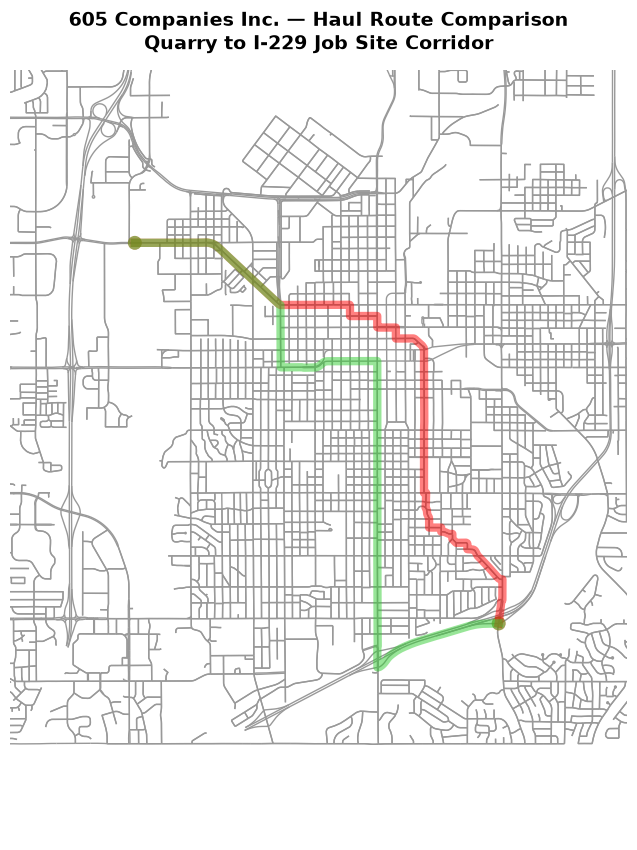

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("Generating zoomed, high-contrast route map...")

# 1. Plot the routes and capture the figure/axis objects
fig, ax = ox.plot_graph_routes(
    G, 
    routes=[route_distance, route_time], 
    route_colors=['red', 'limegreen'], 
    route_linewidths=6,  # Thicker lines for visibility
    node_size=0, 
    bgcolor='white',
    show=False, 
    close=False,
    figsize=(10, 10)
)

# 2. Automatically zoom in (crop) around the actual coordinates of the routes
# Extract all node coordinates from both routes to find the bounding box
node_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in set(route_distance + route_time)]
lats = [coord[0] for coord in node_coords]
lons = [coord[1] for coord in node_coords]

# Add a small padding (e.g., 0.02 degrees) around the bounding box
margin = 0.02
ax.set_xlim(min(lons) - margin, max(lons) + margin)
ax.set_ylim(min(lats) - margin, max(lats) + margin)

# 3. Add professional styling, title, and clear legend
plt.title("605 Companies Inc. — Haul Route Comparison\nQuarry to I-229 Job Site Corridor", fontsize=14, fontweight='bold', pad=15, color='gray')

legend_elements = [
    Line2D([0], [0], color='red', lw=4, label='Distance-Optimized (Standard GPS: 78 nodes)'),
    Line2D([0], [0], color='limegreen', lw=4, label='Time-Optimized (Commercial Haul: 75 nodes)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=10)

plt.show()